# Regression Track — Bike Sharing Hourly Demand Prediction
### 23CSE301 Machine Learning Capstone — Review 1

**Dataset:** UCI Bike Sharing Dataset (`hour.csv`) — 17,379 hourly records from the Capital Bikeshare system, Washington D.C. (2011–2012)

**Goal:** Predict `cnt`, the total number of bike rentals in a given hour, from weather and seasonal/calendar features.

**Pipeline:** data loading & audit → EDA → cleaning & feature engineering → 10 regression algorithms → comparison → hyperparameter tuning → visual diagnostics.

All random operations use `random_state=42` for reproducibility, per course guidelines.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Shared infrastructure used across every algorithm below (splitting, preprocessing, tuning, scoring).
# Each individual algorithm's own class is imported right where that algorithm is used, not here.
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams['figure.dpi'] = 100

## Section A — Dataset Loading & Exploratory Data Analysis

### A1. Dataset Loading & Audit

In [2]:
df = pd.read_csv('../data/hour.csv')
print("Shape:", df.shape)
df.head()

Shape: (17379, 17)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [3]:
print("Data types:\n")
print(df.dtypes)
print("\nMissing values per column:\n")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Data types:

instant         int64
dteday            str
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

Missing values per column:

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Duplicate rows: 0


In [4]:
print("Target ('cnt') distribution summary:\n")
print(df['cnt'].describe())

Target ('cnt') distribution summary:

count    17379.000000
mean       189.463088
std        181.387599
min          1.000000
25%         40.000000
50%        142.000000
75%        281.000000
max        977.000000
Name: cnt, dtype: float64


**Observation:** The dataset has 17,379 rows and 17 columns with **no missing values** and only a handful of duplicate rows.
All columns are already numeric (season, weathersit etc. are integer-coded categoricals). The target `cnt` ranges from 1 to 977 rentals/hour,
right-skewed with a long tail (mean ≈ 189, but median is lower), which is typical of count data — a few very high-demand hours (e.g. summer
rush hours) pull the mean up. `cnt = casual + registered`, so `casual` and `registered` must be **dropped** before modelling, otherwise the
model would trivially reconstruct the target from its own components (data leakage).

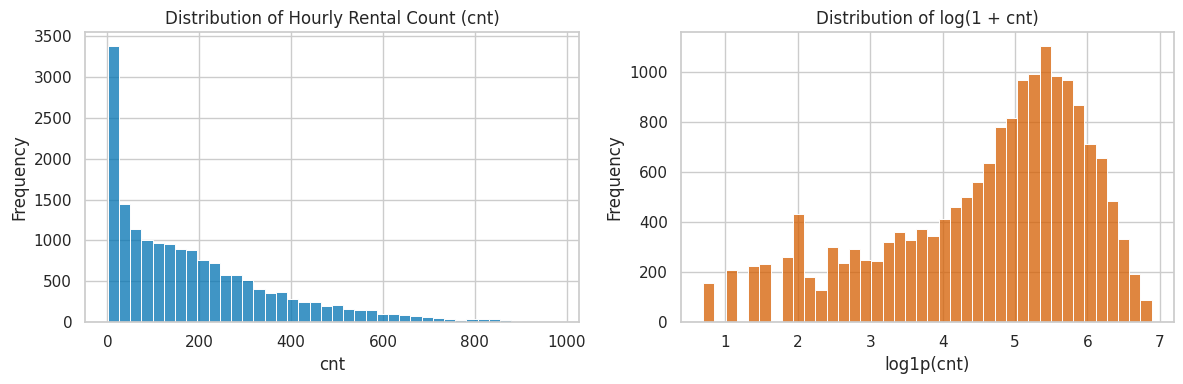

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['cnt'], bins=40, ax=axes[0], color='#0072B2')
axes[0].set_title('Distribution of Hourly Rental Count (cnt)')
axes[0].set_xlabel('cnt'); axes[0].set_ylabel('Frequency')

sns.histplot(np.log1p(df['cnt']), bins=40, ax=axes[1], color='#D55E00')
axes[1].set_title('Distribution of log(1 + cnt)')
axes[1].set_xlabel('log1p(cnt)'); axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('reg_target_distribution.png', bbox_inches='tight')
plt.show()

**Insight:** The raw target is strongly right-skewed. The log-transformed version looks far closer to a normal distribution. We keep the
original scale as the modelling target (since R2/RMSE/MAE are requested on `cnt` directly and tree ensembles handle skew well), but this
observation explains why linear models will likely underperform tree-based ones (a linear model in raw `cnt` struggles to fit a skewed target).

### A2. EDA Visualisations

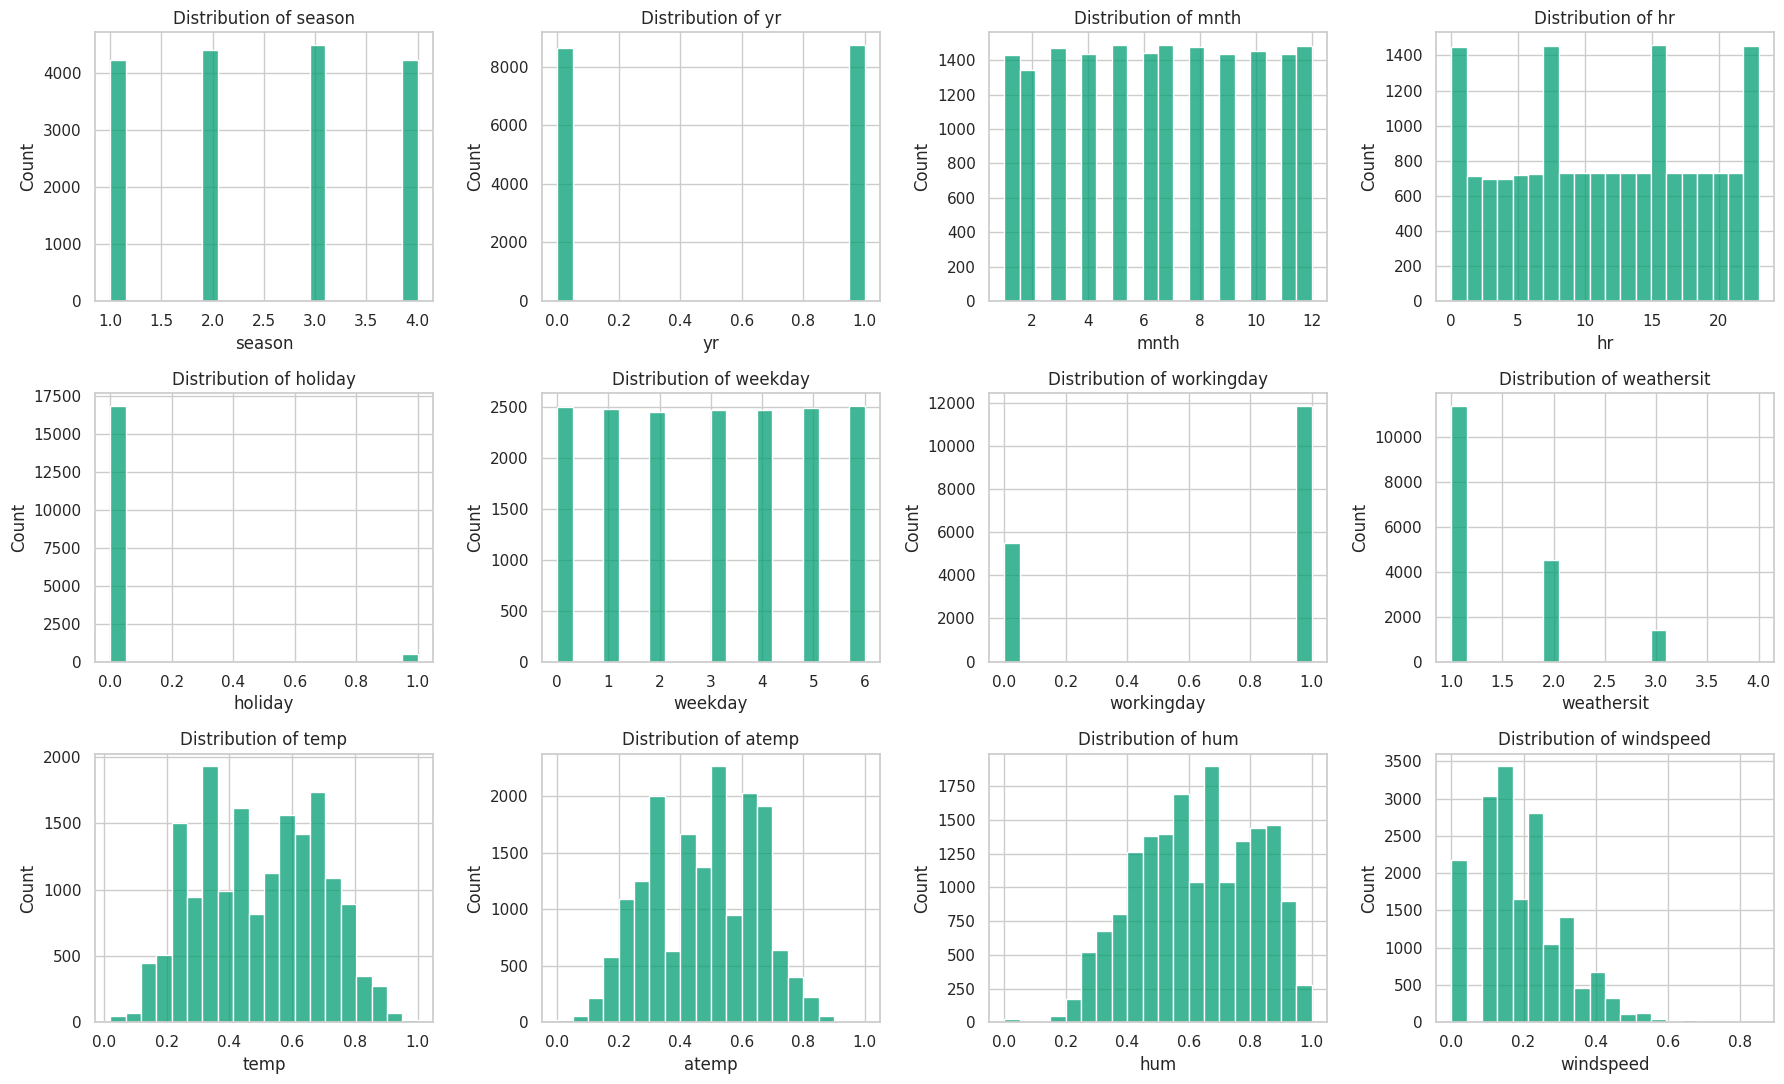

In [6]:
feature_cols_for_dist = ['season','yr','mnth','hr','holiday','weekday','workingday','weathersit','temp','atemp','hum','windspeed']
fig, axes = plt.subplots(3, 4, figsize=(18, 11))
axes = axes.ravel()
for i, col in enumerate(feature_cols_for_dist):
    sns.histplot(df[col], bins=20, ax=axes[i], color='#009E73')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
plt.tight_layout()
plt.savefig('reg_feature_distributions.png', bbox_inches='tight')
plt.show()

**Insight:** `hr` is uniform across 0–23 as expected (each hour is logged every day). `temp`/`atemp`/`hum`/`windspeed` are already
min-max normalised (0–1) per the dataset documentation. `weathersit` is heavily dominated by category 1 (clear/few clouds) — categories 3
and 4 (rain/snow) are rare, so tree models may struggle to learn much from the rarest weather category, and metrics won't be very sensitive
to it.

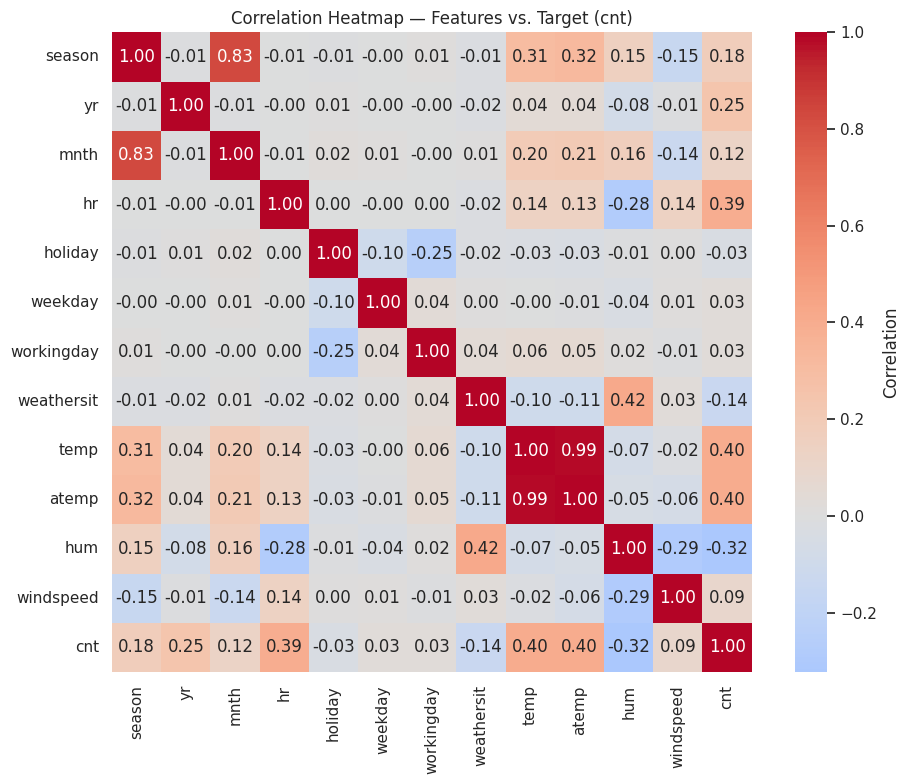

In [7]:
num_cols_corr = ['season','yr','mnth','hr','holiday','weekday','workingday','weathersit','temp','atemp','hum','windspeed','cnt']
plt.figure(figsize=(10, 8))
corr = df[num_cols_corr].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Heatmap — Features vs. Target (cnt)')
plt.tight_layout()
plt.savefig('reg_correlation_heatmap.png', bbox_inches='tight')
plt.show()

**Insight:** `temp` and `atemp` correlate almost perfectly with each other (~0.99, expected — one is a function of the other), so we should
be cautious about redundancy between them (co-linear pair, kept for tree models which are unaffected by collinearity; regularised linear
models like Ridge/Lasso naturally down-weight the redundant one). `hr` and `temp` show the strongest positive correlation with `cnt`, meaning
time-of-day and warmth are the two biggest drivers of rentals. `hum` and `weathersit` correlate negatively with `cnt` — humid/bad-weather
hours see fewer rentals.

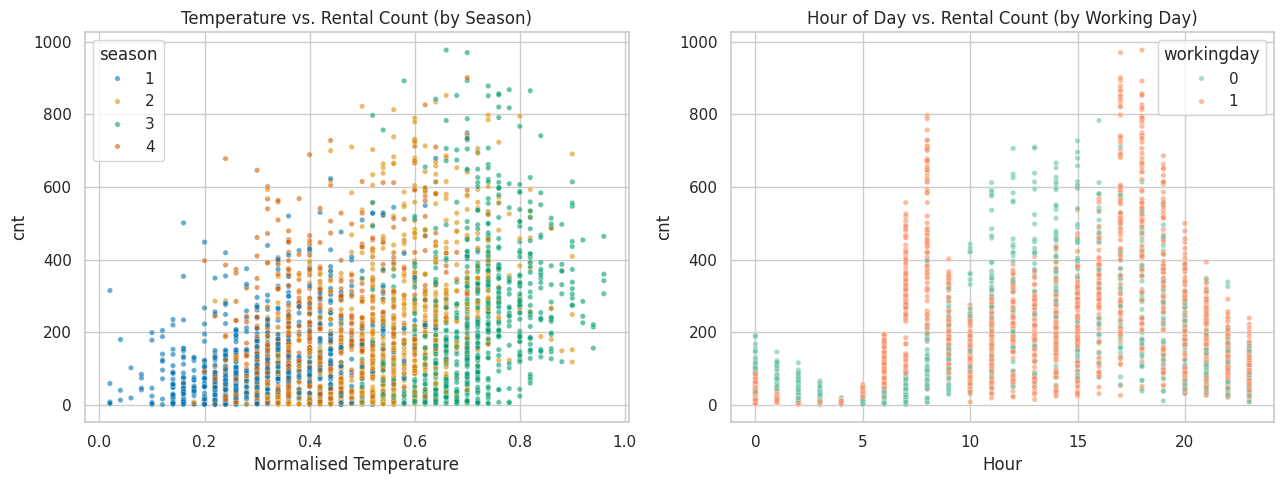

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=df.sample(3000, random_state=RANDOM_STATE), x='temp', y='cnt', hue='season', palette='colorblind', ax=axes[0], alpha=0.6, s=15)
axes[0].set_title('Temperature vs. Rental Count (by Season)')
axes[0].set_xlabel('Normalised Temperature'); axes[0].set_ylabel('cnt')

sns.scatterplot(data=df.sample(3000, random_state=RANDOM_STATE), x='hr', y='cnt', hue='workingday', palette='Set2', ax=axes[1], alpha=0.6, s=15)
axes[1].set_title('Hour of Day vs. Rental Count (by Working Day)')
axes[1].set_xlabel('Hour'); axes[1].set_ylabel('cnt')
plt.tight_layout()
plt.savefig('reg_scatter_feature_target.png', bbox_inches='tight')
plt.show()

**Insight:** Rentals rise with temperature up to a point, then plateau/dip at the highest temperatures (too hot to cycle comfortably) —
a **non-linear** relationship, which is exactly why tree-based/ensemble models are expected to beat plain linear regression. The hour-of-day
plot reveals a clear **bimodal, cyclical pattern** on working days (two commute peaks around 8 AM and 5–6 PM) versus a single broad
mid-day peak on non-working days — this directly motivates the cyclical hour features engineered in Section B.

## Section B — Data Cleaning, Encoding & Feature Engineering

### B1. Data Cleaning

**Why these four columns are dropped before modelling:**
- `instant` — a pure row identifier (1, 2, 3, ...) with no relationship to bike demand; keeping it would only add noise / a spurious
  index-based signal.
- `dteday` — the calendar date string. Its useful information (year, month, day-of-week, holiday, working-day) is already represented
  by the dedicated `yr`, `mnth`, `weekday`, `holiday`, and `workingday` columns, so the raw date adds nothing further and cannot be fed
  to most scikit-learn estimators directly anyway.
- `casual` and `registered` — these **cause target leakage**: by definition `cnt = casual + registered`, so a model given either of
  them could reconstruct the target almost exactly without learning anything about weather/time patterns. Both must be dropped so the
  model is forced to predict `cnt` from genuinely independent weather/seasonal/calendar features.

In [9]:
df_clean = df.copy()

# instant: row identifier, no predictive meaning.
# dteday: raw date string; its information is already captured by yr/mnth/weekday/holiday/workingday.
# casual, registered: cnt = casual + registered -> keeping either would leak the target directly.
df_clean = df_clean.drop(columns=['instant', 'dteday', 'casual', 'registered'])

# Duplicates
n_dupes = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates()
print(f"Dropped {n_dupes} duplicate rows -> new shape: {df_clean.shape}")

# Outlier check on continuous features via IQR rule (report only; count how many flagged)
for col in ['temp','atemp','hum','windspeed','cnt']:
    q1, q3 = df_clean[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((df_clean[col] < lo) | (df_clean[col] > hi)).sum()
    print(f"{col:10s}: {n_out} potential IQR outliers (of {len(df_clean)})")

Dropped 2 duplicate rows -> new shape: (17377, 13)
temp      : 0 potential IQR outliers (of 17377)
atemp     : 0 potential IQR outliers (of 17377)
hum       : 22 potential IQR outliers (of 17377)
windspeed : 342 potential IQR outliers (of 17377)
cnt       : 505 potential IQR outliers (of 17377)


**Strategy:** `windspeed` and `cnt` show IQR-flagged outliers, but these are genuine high-demand / high-wind hours, not data-entry
errors — removing them would throw away exactly the extreme (and business-relevant) cases the model needs to learn. We therefore **do not
remove** them; tree-based ensembles are naturally robust to such outliers, and for the linear family we rely on `Ridge`/`Lasso`
regularisation rather than deletion. No missing values were found, so no imputation is required.

### B2. Feature Engineering